## Step 1 - Workflow Cell 1
Visualize distributions or model behavior for this stage.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
print(pd.__version__)

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100) 

print("Libraries imported successfully!")

2.3.0
Libraries imported successfully!


## Step 2 - Workflow Cell 2
Load input data and inspect basic structure for this step.

In [2]:
df = pd.read_csv('../../data/house/satilir_properties_house.csv')
print("Data loaded successfully!")
# - Dataset shape (hint: use df.shape)
print("Dataset shape:", df.shape)
# - Number of observations (hint: df.shape[0] gives rows)
print("Number of observations:", df.shape[0])
# - Number of features (hint: df.shape[1] gives columns)
print("Number of features:", df.shape[1])

Data loaded successfully!
Dataset shape: (1195, 25)
Number of observations: 1195
Number of features: 25


## Step 3 - Workflow Cell 3
Run this notebook step and prepare outputs for the next stage.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1195 entries, 0 to 1194
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   price                     1195 non-null   int64  
 1   rooms                     1194 non-null   float64
 2   area_m2                   935 non-null    float64
 3   land_area_sot             1195 non-null   float64
 4   floor                     1194 non-null   float64
 5   has_document              1195 non-null   object 
 6   address                   1195 non-null   object 
 7   avtodayanacaq             1195 non-null   object 
 8   balkon                    1195 non-null   object 
 9   duzelme                   1195 non-null   object 
 10  esyali                    1195 non-null   object 
 11  hovuz                     1195 non-null   object 
 12  internet                  1195 non-null   object 
 13  isiq                      1195 non-null   object 
 14  kabel_tv

## Step 4 - Workflow Cell 4
Run this notebook step and prepare outputs for the next stage.

In [4]:
df.head()

,price,rooms,area_m2,land_area_sot,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirli
0,125000,3.0,100.0,1.7,1.0,Yes,Xırdalan,No,Yes,No,No,No,Yes,Yes,Yes,Yes,No,No,No,Yes,Yes,No,Yes,No,Yes
1,145000,3.0,110.0,2.2,1.0,Yes,Xırdalan,Yes,Yes,No,No,No,Yes,Yes,Yes,Yes,No,No,No,Yes,Yes,Yes,Yes,No,Yes
2,35000,1.0,60.0,0.6,1.0,Yes,"Bakı, Abşeron, Mehdiabad",No,No,No,No,No,Yes,Yes,Yes,Yes,No,No,No,No,Yes,Yes,Yes,No,Yes
3,279000,6.0,250.0,2.5,3.0,Yes,"Bakı, Binəqədi, Biləcəri qəs., metro Avtovağzal",Yes,Yes,No,Yes,No,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes
4,75000,6.0,NaN,4.0,2.0,Yes,Xızı,No,No,No,No,No,No,Yes,No,No,No,No,No,No,Yes,Yes,Yes,No,No


## Baseline Visual Profiling (Before Cleaning)
Create a pre-cleaning snapshot and reusable plotting functions to compare distributions before and after cleaning.

In [5]:
# Snapshot raw dataset for before/after visual diagnostics
df_before_cleaning = df.copy()

key_numeric_features = [
    c for c in ["price", "area_m2", "land_area_sot", "rooms", "floor"]
    if c in df_before_cleaning.columns
]

def plot_before_after_distributions(before_df, after_df, numeric_cols, bins=40):
    cols = [
        c for c in numeric_cols
        if c in before_df.columns and c in after_df.columns
    ]
    if not cols:
        print("No shared numeric columns available for before/after comparison.")
        return

    fig, axes = plt.subplots(len(cols), 2, figsize=(12, 3.2 * len(cols)))
    if len(cols) == 1:
        axes = np.array([axes])

    for i, col in enumerate(cols):
        sns.histplot(before_df[col].dropna(), bins=bins, kde=True, color="#4C72B0", ax=axes[i, 0])
        axes[i, 0].set_title(f"Before cleaning: {col}")
        axes[i, 0].set_xlabel(col)

        sns.histplot(after_df[col].dropna(), bins=bins, kde=True, color="#55A868", ax=axes[i, 1])
        axes[i, 1].set_title(f"After cleaning: {col}")
        axes[i, 1].set_xlabel(col)

    plt.tight_layout()
    plt.show()


def plot_correlation_heatmap(dataframe, title):
    numeric_df = dataframe.select_dtypes(include=[np.number])
    if numeric_df.shape[1] < 2:
        print("Not enough numeric columns to build a correlation heatmap.")
        return

    corr = numeric_df.corr(numeric_only=True)
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")
    plt.title(title)
    plt.tight_layout()
    plt.show()


print("Tracked numeric features for visualization:", key_numeric_features)

Tracked numeric features for visualization: ['price', 'area_m2', 'land_area_sot', 'rooms', 'floor']


## Step 6 - Workflow Cell 6
Run this notebook step and prepare outputs for the next stage.

In [6]:
print(df.duplicated().sum())

18


## Step 7 - Workflow Cell 7
Run this notebook step and prepare outputs for the next stage.

In [7]:
dup_rows = df[df.duplicated(keep=False)]  # all duplicates grouped together
dup_rows.sort_index()  # optional: keep original order

,price,rooms,area_m2,land_area_sot,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirli
42,398000,4.0,NaN,6.0,1.0,Yes,"Bakı, Xəzər, Mərdəkan",Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes
44,300000,4.0,NaN,5.0,1.0,Yes,"Bakı, Xəzər, Mərdəkan",Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes
70,125000,4.0,120.0,1.9,1.0,Yes,"Bakı, Xəzər, Binə qəs.",No,No,No,No,No,No,Yes,No,Yes,No,No,Yes,No,Yes,Yes,Yes,No,Yes
72,125000,4.0,120.0,1.9,1.0,Yes,"Bakı, Xəzər, Binə qəs.",No,No,No,No,No,No,Yes,No,Yes,No,No,Yes,No,Yes,Yes,Yes,No,Yes
79,110000,4.0,200.0,2.5,2.0,Yes,"Bakı, Sabunçu, Savalan qəs.",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
220,15000,2.0,50.0,1.0,1.0,Yes,"Bakı, Abşeron, Masazır",Yes,No,No,No,No,Yes,Yes,No,No,No,No,No,No,Yes,Yes,Yes,No,Yes
301,110000,4.0,200.0,2.5,2.0,Yes,"Bakı, Sabunçu, Savalan qəs.",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
318,210000,4.0,NaN,3.0,1.0,Yes,"Bakı, Xəzər, Şüvəlan",Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes
343,95000,4.0,120.0,1.2,2.0,Yes,Xırdalan,No,Yes,No,No,No,No,Yes,No,Yes,No,No,No,No,Yes,Yes,Yes,No,Yes
351,85000,3.0,100.0,2.0,1.0,Yes,"Bakı, Abşeron, Mehdiabad",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No


## Step 8 - Workflow Cell 8
Run this notebook step and prepare outputs for the next stage.

In [8]:
df = df.drop_duplicates(keep="first").reset_index(drop=True)

## Step 9 - Workflow Cell 9
Run this notebook step and prepare outputs for the next stage.

In [9]:
print(df.duplicated().sum())

0


## Step 10 - Workflow Cell 10
Run this notebook step and prepare outputs for the next stage.

In [10]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Number of numerical columns:", len(num_cols))
print("Numerical columns:", num_cols)

Number of numerical columns: 5
Numerical columns: ['price', 'rooms', 'area_m2', 'land_area_sot', 'floor']


## Step 11 - Workflow Cell 11
Run this notebook step and prepare outputs for the next stage.

In [11]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Number of categorical columns:", len(cat_cols))
print("Categorical columns:", cat_cols)

Number of categorical columns: 20
Categorical columns: ['has_document', 'address', 'avtodayanacaq', 'balkon', 'duzelme', 'esyali', 'hovuz', 'internet', 'isiq', 'kabel_tv', 'kombi', 'kondisioner', 'lift', 'merkezi_qizdirici_sistem', 'metbex_mebeli', 'pvc_pencere', 'qaz', 'su', 'telefon', 'temirli']


## Step 12 - Workflow Cell 12
Run this notebook step and prepare outputs for the next stage.

In [12]:
print("Unique values for each column: \n", df[cat_cols].nunique().sort_values(ascending=False))

Unique values for each column: 
 address                     124
has_document                  2
telefon                       2
su                            2
qaz                           2
pvc_pencere                   2
metbex_mebeli                 2
merkezi_qizdirici_sistem      2
lift                          2
kondisioner                   2
kombi                         2
kabel_tv                      2
isiq                          2
internet                      2
hovuz                         2
esyali                        2
duzelme                       2
balkon                        2
avtodayanacaq                 2
temirli                       2
dtype: int64


## Step 13 - Workflow Cell 13
Run this notebook step and prepare outputs for the next stage.

In [13]:
mis_values = df.isnull().sum()
mis_percent = (mis_values / len(df)) * 100

df_mis = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": mis_values,
    "Percentage": mis_percent
})

df_mis = df_mis[df_mis["Missing Values"] > 0].sort_values(by="Percentage", ascending=False).reset_index(drop=True)

print(f"Number of features with missing values: {df_mis.shape[0]}")
df_mis

Number of features with missing values: 3


,Column,Missing Values,Percentage
0,area_m2,252,21.410365
1,rooms,1,0.084962
2,floor,1,0.084962


## Step 14 - Workflow Cell 14
Run this notebook step and prepare outputs for the next stage.

In [14]:
before_shape = df.shape

df_clean = df[df["land_area_sot"].notna()].reset_index(drop=True).copy()

print("Rows kept where land_area_sot is not null.")
print("Before:", before_shape)
print("After:", df_clean.shape)
print("Rows removed:", before_shape[0] - df_clean.shape[0])

Rows kept where land_area_sot is not null.
Before: (1177, 25)
After: (1177, 25)
Rows removed: 0


## Step 15 - Workflow Cell 15
Run this notebook step and prepare outputs for the next stage.

In [15]:
# Display null values of each column (only columns that have nulls)
null_counts = df_clean.isnull().sum()
null_counts = null_counts[null_counts > 0].sort_values(ascending=False)

if null_counts.empty:
    print("No null values found in any column.")
else:
    print("Columns with null values:")
    display(null_counts.to_frame(name="null_count"))

Columns with null values:


,null_count
area_m2,252
rooms,1
floor,1


## Step 16 - Workflow Cell 16
Run this notebook step and prepare outputs for the next stage.

In [16]:
missing_rooms_or_floor = df_clean[df_clean["rooms"].isnull() | df_clean["floor"].isnull()]

print(f"Rows with missing rooms or floor: {missing_rooms_or_floor.shape[0]}")
display(missing_rooms_or_floor)

Rows with missing rooms or floor: 1


,price,rooms,area_m2,land_area_sot,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirli
198,500000,NaN,NaN,25.0,NaN,Yes,"Bakı, Xəzər, Şüvəlan",No,No,No,No,No,No,Yes,No,No,No,No,No,No,No,Yes,Yes,Yes,No


## Step 17 - Workflow Cell 17
Run this notebook step and prepare outputs for the next stage.

In [17]:
df_clean = df_clean.dropna(subset=["rooms", "floor"]).reset_index(drop=True)

## Step 18 - Workflow Cell 18
Run this notebook step and prepare outputs for the next stage.

In [18]:
df_clean.isnull().sum()

price                         0
rooms                         0
area_m2                     251
land_area_sot                 0
floor                         0
has_document                  0
address                       0
avtodayanacaq                 0
balkon                        0
duzelme                       0
esyali                        0
hovuz                         0
internet                      0
isiq                          0
kabel_tv                      0
kombi                         0
kondisioner                   0
lift                          0
merkezi_qizdirici_sistem      0
metbex_mebeli                 0
pvc_pencere                   0
qaz                           0
su                            0
telefon                       0
temirli                       0
dtype: int64

## Step 19 - Workflow Cell 19
Run this notebook step and prepare outputs for the next stage.

In [19]:
df_clean = df_clean[df_clean["price"] <= 60_000_000].reset_index(drop=True)

## Step 20 - Workflow Cell 20
Run this notebook step and prepare outputs for the next stage.

In [20]:
df_clean[df_clean['land_area_sot']==500]

,price,rooms,area_m2,land_area_sot,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirli
589,40000,2.0,40.0,500.0,1.0,No,"Bakı, Sabunçu, Zabrat qəs.",No,No,No,No,No,No,Yes,No,Yes,No,No,No,Yes,No,Yes,Yes,No,No


## Step 21 - Workflow Cell 21
Run this notebook step and prepare outputs for the next stage.

In [21]:
# 1) Delete rows where land_area_sot is 500 or 110
df_clean = df_clean[~df_clean["land_area_sot"].isin([500, 110])].reset_index(drop=True)

# 2) Replace specific land_area_sot values
land_replacements = {
    150: 1.5,
    250: 2.5,
    80: 2,
    162: 1.62,
    260: 6,
    163: 1.63,
}
df_clean["land_area_sot"] = df_clean["land_area_sot"].replace(land_replacements)

# 3) Replace area=13 and land=200 with area=200 and land=13
swap_mask = (df_clean["area_m2"] == 13) & (df_clean["land_area_sot"] == 200)
df_clean.loc[swap_mask, ["area_m2", "land_area_sot"]] = [200, 13]

## Step 22 - Workflow Cell 22
Run this notebook step and prepare outputs for the next stage.

In [22]:
# Replace land_area_sot value: 100 -> 1.15
replacement_mask = df_clean["land_area_sot"] == 100
replaced_count = replacement_mask.sum()

df_clean.loc[replacement_mask, "land_area_sot"] = 1.15

## Step 23 - Workflow Cell 23
Visualize distributions or model behavior for this stage.

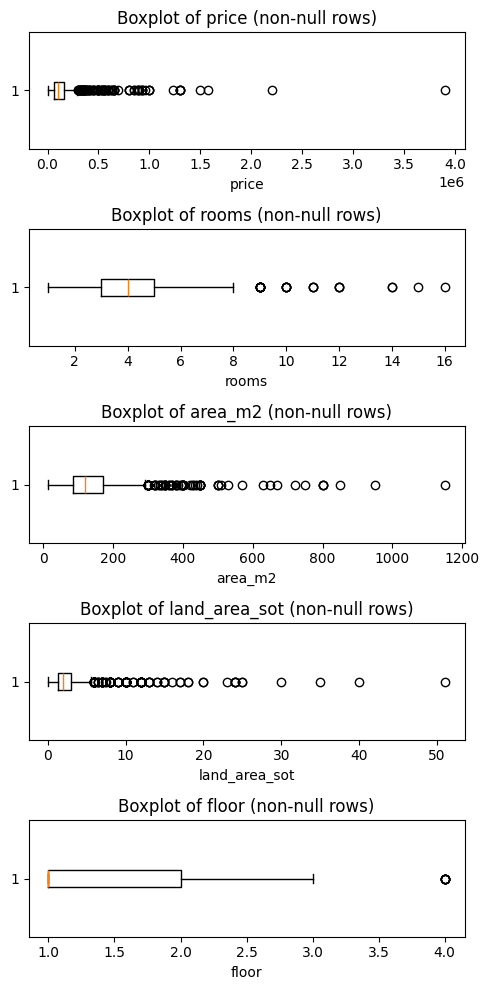

In [23]:
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
df_non_null_numeric = df_clean[numeric_cols].dropna()

if len(numeric_cols) == 0:
    print("No numerical columns found.")
elif df_non_null_numeric.empty:
    print("No rows left after filtering non-null numeric values.")
else:
    fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(5, 2 * len(numeric_cols)))
    if len(numeric_cols) == 1:
        axes = [axes]

    for i, col in enumerate(numeric_cols):
        axes[i].boxplot(df_non_null_numeric[col], vert=False)
        axes[i].set_title(f"Boxplot of {col} (non-null rows)")
        axes[i].set_xlabel(col)

    plt.tight_layout()
    plt.show()

## Step 24 - Workflow Cell 24
Run this notebook step and prepare outputs for the next stage.

In [24]:
df_clean[df_clean['land_area_sot']>=40]

,price,rooms,area_m2,land_area_sot,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirli
264,1300000,5.0,500.0,51.0,3.0,Yes,"Bakı, Sabunçu, Bilgəh qəs.",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
952,395000,10.0,292.0,40.0,2.0,Yes,Siyazən,Yes,Yes,No,Yes,Yes,Yes,Yes,No,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes


## Step 25 - Workflow Cell 25
Run this notebook step and prepare outputs for the next stage.

In [25]:
display(df_clean[df_clean["area_m2"].isnull()].head(5))

,price,rooms,area_m2,land_area_sot,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirli
4,75000,6.0,NaN,4.0,2.0,Yes,Xızı,No,No,No,No,No,No,Yes,No,No,No,No,No,No,Yes,Yes,Yes,No,No
5,390000,4.0,NaN,5.0,1.0,Yes,"Bakı, Xəzər, Mərdəkan",Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,No,Yes,Yes,Yes,Yes
6,480000,4.0,NaN,6.0,1.0,Yes,"Bakı, Xəzər, Mərdəkan",Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes
7,245000,4.0,NaN,3.0,1.0,Yes,"Bakı, Xəzər, Mərdəkan",Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes
8,770000,5.0,NaN,5.5,2.0,Yes,"Bakı, Xəzər, Mərdəkan",Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes


## Step 26 - Workflow Cell 26
Run this notebook step and prepare outputs for the next stage.

In [26]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

cols_for_impute = [c for c in ["area_m2", "price", "land_area_sot", "floor", "rooms"] if c in df_clean.columns]
if "area_m2" not in cols_for_impute:
    raise KeyError("'area_m2' column not found in df_clean")

imputer = IterativeImputer(random_state=42, max_iter=20, sample_posterior=False)
imputed_array = imputer.fit_transform(df_clean[cols_for_impute])
area_idx = cols_for_impute.index("area_m2")
df_clean["area_m2"] = imputed_array[:, area_idx]

df_clean["area_m2"].isnull().sum()

0

## Step 27 - Workflow Cell 27
Run this notebook step and prepare outputs for the next stage.

In [27]:
df_clean

,price,rooms,area_m2,land_area_sot,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirli
0,125000,3.0,100.000000,1.7,1.0,Yes,Xırdalan,No,Yes,No,No,No,Yes,Yes,Yes,Yes,No,No,No,Yes,Yes,No,Yes,No,Yes
1,145000,3.0,110.000000,2.2,1.0,Yes,Xırdalan,Yes,Yes,No,No,No,Yes,Yes,Yes,Yes,No,No,No,Yes,Yes,Yes,Yes,No,Yes
2,35000,1.0,60.000000,0.6,1.0,Yes,"Bakı, Abşeron, Mehdiabad",No,No,No,No,No,Yes,Yes,Yes,Yes,No,No,No,No,Yes,Yes,Yes,No,Yes
3,279000,6.0,250.000000,2.5,3.0,Yes,"Bakı, Binəqədi, Biləcəri qəs., metro Avtovağzal",Yes,Yes,No,Yes,No,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes
4,75000,6.0,204.700091,4.0,2.0,Yes,Xızı,No,No,No,No,No,No,Yes,No,No,No,No,No,No,Yes,Yes,Yes,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1168,64000,3.0,100.000000,4.0,1.0,No,"Bakı, Xəzər, Binə qəs.",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
1169,52000,3.0,90.000000,1.5,1.0,No,"Bakı, Xəzər, Binə qəs.",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
1170,138000,5.0,200.000000,4.0,2.0,Yes,"Bakı, Abşeron, Masazır",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
1171,95000,7.0,170.000000,2.0,2.0,Yes,"Bakı, Abşeron, Saray",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No


## Step 28 - Workflow Cell 28
Visualize distributions or model behavior for this stage.

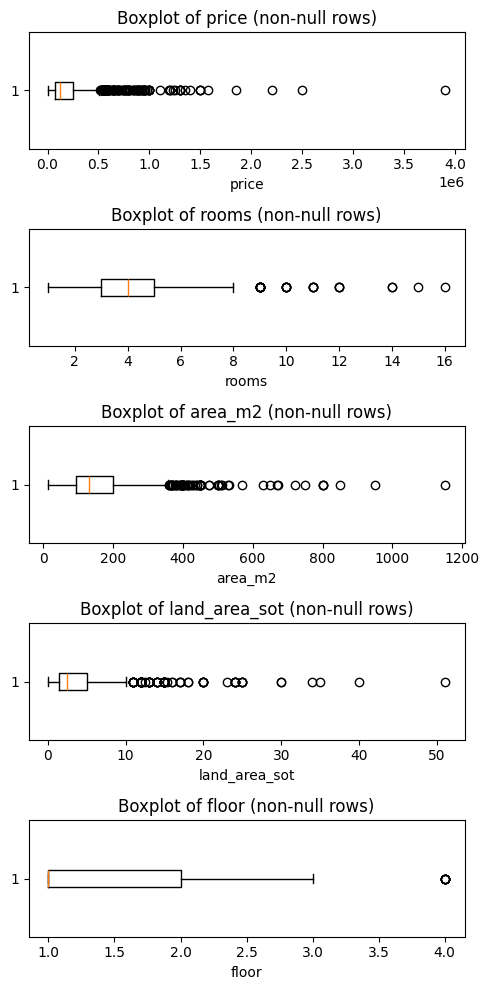

In [28]:
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
df_non_null_numeric = df_clean[numeric_cols].dropna()

if len(numeric_cols) == 0:
    print("No numerical columns found.")
elif df_non_null_numeric.empty:
    print("No rows left after filtering non-null numeric values.")
else:
    fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(5, 2 * len(numeric_cols)))
    if len(numeric_cols) == 1:
        axes = [axes]

    for i, col in enumerate(numeric_cols):
        axes[i].boxplot(df_non_null_numeric[col], vert=False)
        axes[i].set_title(f"Boxplot of {col} (non-null rows)")
        axes[i].set_xlabel(col)

    plt.tight_layout()
    plt.show()

## Step 29 - Workflow Cell 29
Run this notebook step and prepare outputs for the next stage.

In [29]:
# Check duplicates excluding 'address' column
subset_cols = [c for c in df_clean.columns if c != "address"]

dup_mask_excl_address = df_clean.duplicated(subset=subset_cols, keep=False)
dup_rows_excl_address = df_clean[dup_mask_excl_address].sort_values(by=subset_cols).reset_index(drop=True)

print(f"Number of duplicate rows (excluding 'address'): {dup_mask_excl_address.sum()}")
if dup_rows_excl_address.empty:
    print("No duplicates found when excluding 'address'.")
else:
    display(dup_rows_excl_address.head(20))


Number of duplicate rows (excluding 'address'): 10


,price,rooms,area_m2,land_area_sot,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirli
0,53000,2.0,50.000000,1.0,1.0,Yes,"Bakı, Abşeron, Məhəmmədli",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
1,53000,2.0,50.000000,1.0,1.0,Yes,"Bakı, Abşeron, Masazır",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
2,55000,3.0,70.000000,1.0,1.0,No,Xırdalan,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
3,55000,3.0,70.000000,1.0,1.0,No,"Bakı, Binəqədi, Binəqədi qəs., metro Azadlıq",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
4,85000,3.0,100.000000,2.0,1.0,Yes,"Bakı, Abşeron, Mehdiabad",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
5,85000,3.0,100.000000,2.0,1.0,Yes,"Bakı, Abşeron, Məhəmmədli",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
6,210000,4.0,131.848482,3.0,1.0,Yes,"Bakı, Xəzər, Şüvəlan",Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes
7,210000,4.0,131.848482,3.0,1.0,Yes,"Bakı, Xəzər, Mərdəkan",Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes
8,220000,4.0,133.307181,3.0,1.0,Yes,"Bakı, Xəzər, Mərdəkan",Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes
9,220000,4.0,133.307181,3.0,1.0,Yes,"Bakı, Xəzər, Buzovna",Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes


## Step 30 - Workflow Cell 30
Run this notebook step and prepare outputs for the next stage.

In [30]:
df_clean.isnull().sum().sum()

0

## Post-Cleaning Visual Diagnostics
Compare distributions before and after cleaning, inspect cleaned-feature correlations, and review key scatter patterns versus price.

Before vs after distribution comparison:


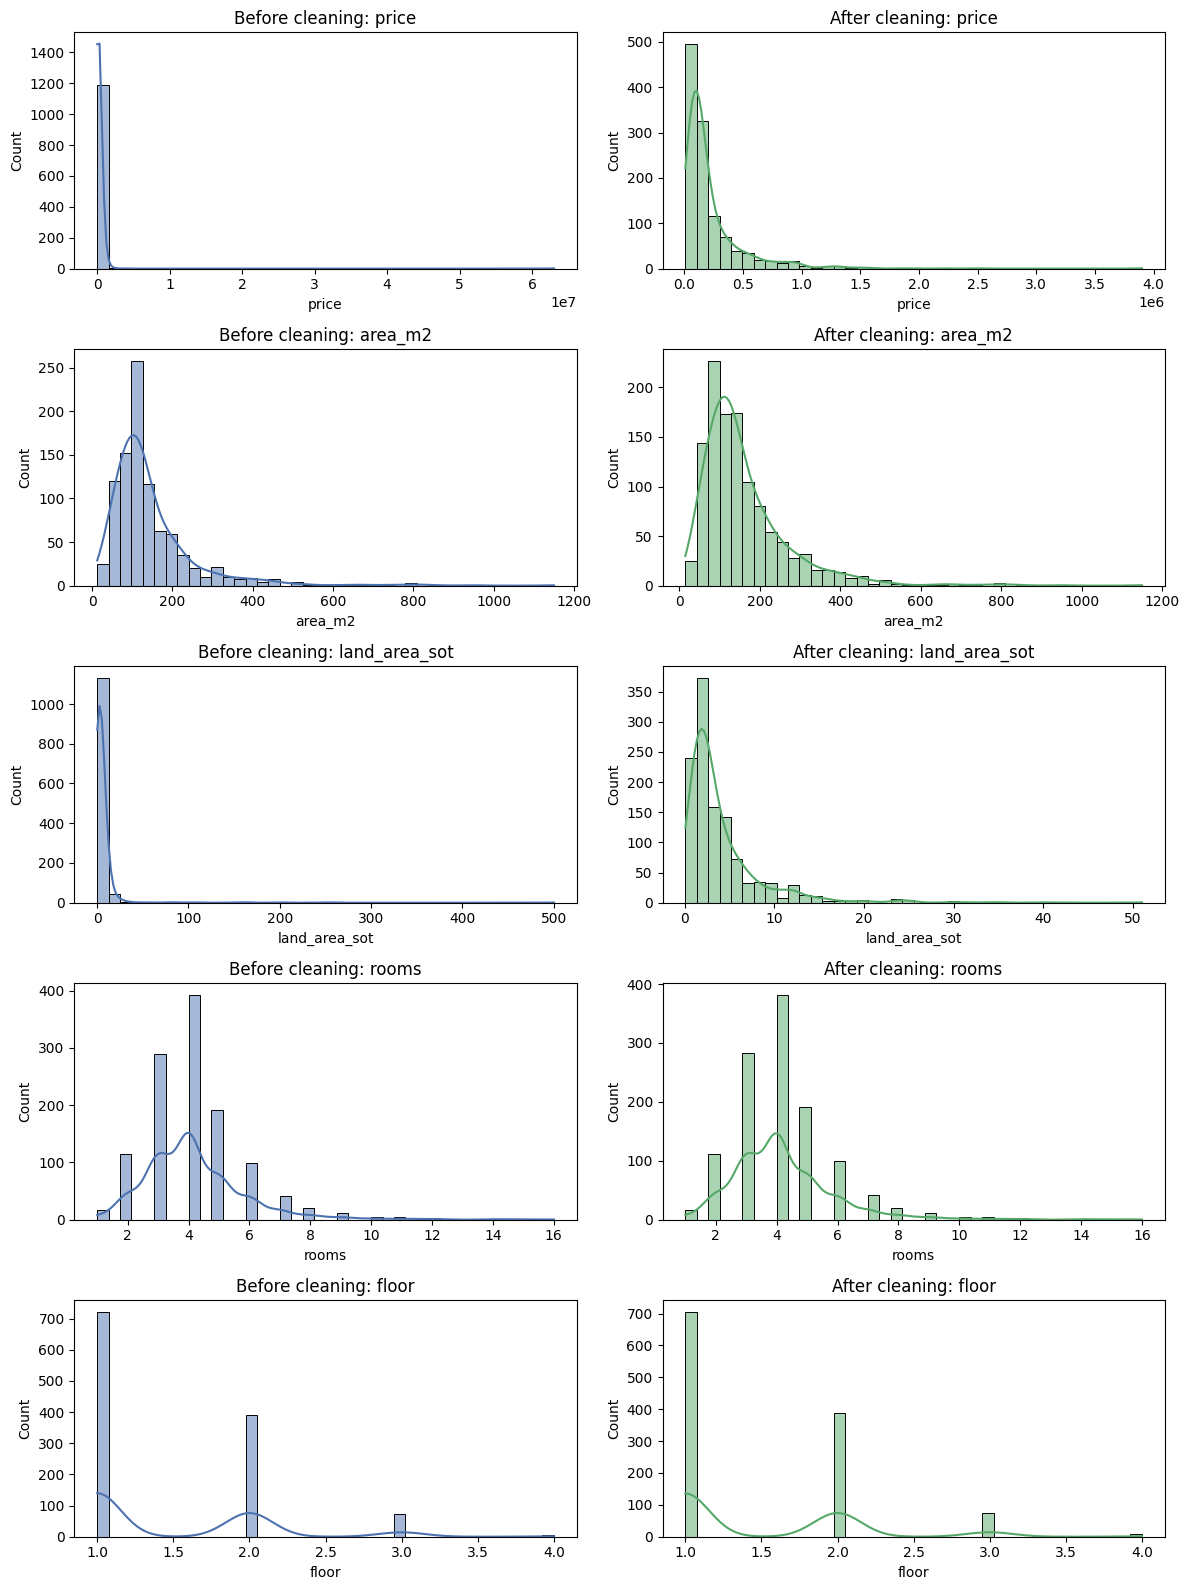

Correlation heatmap on cleaned dataset:


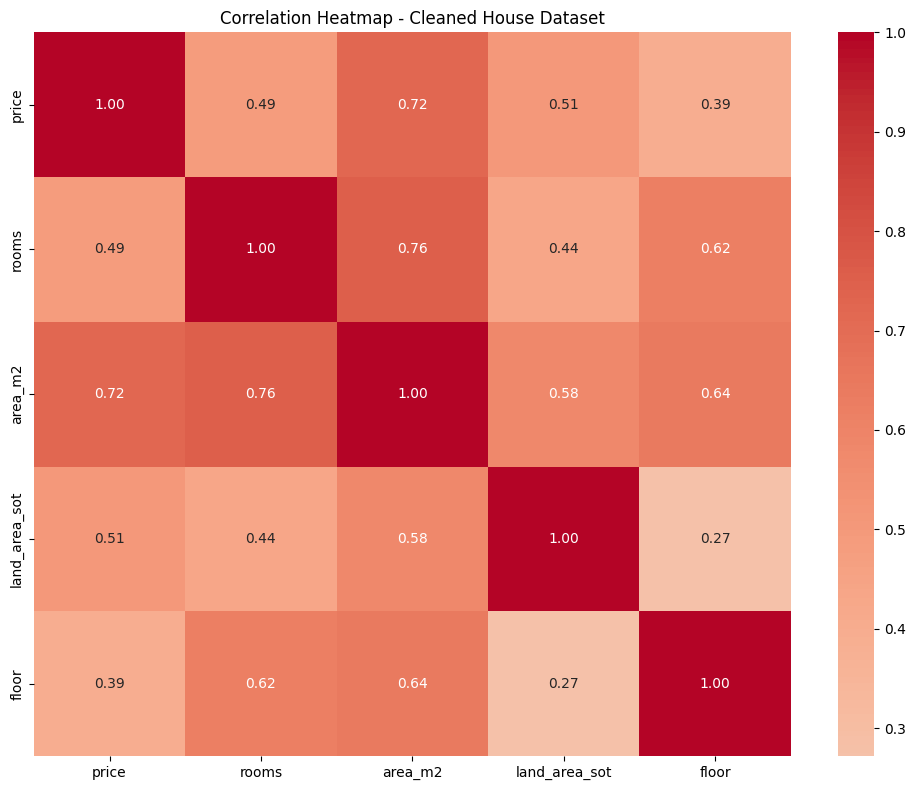

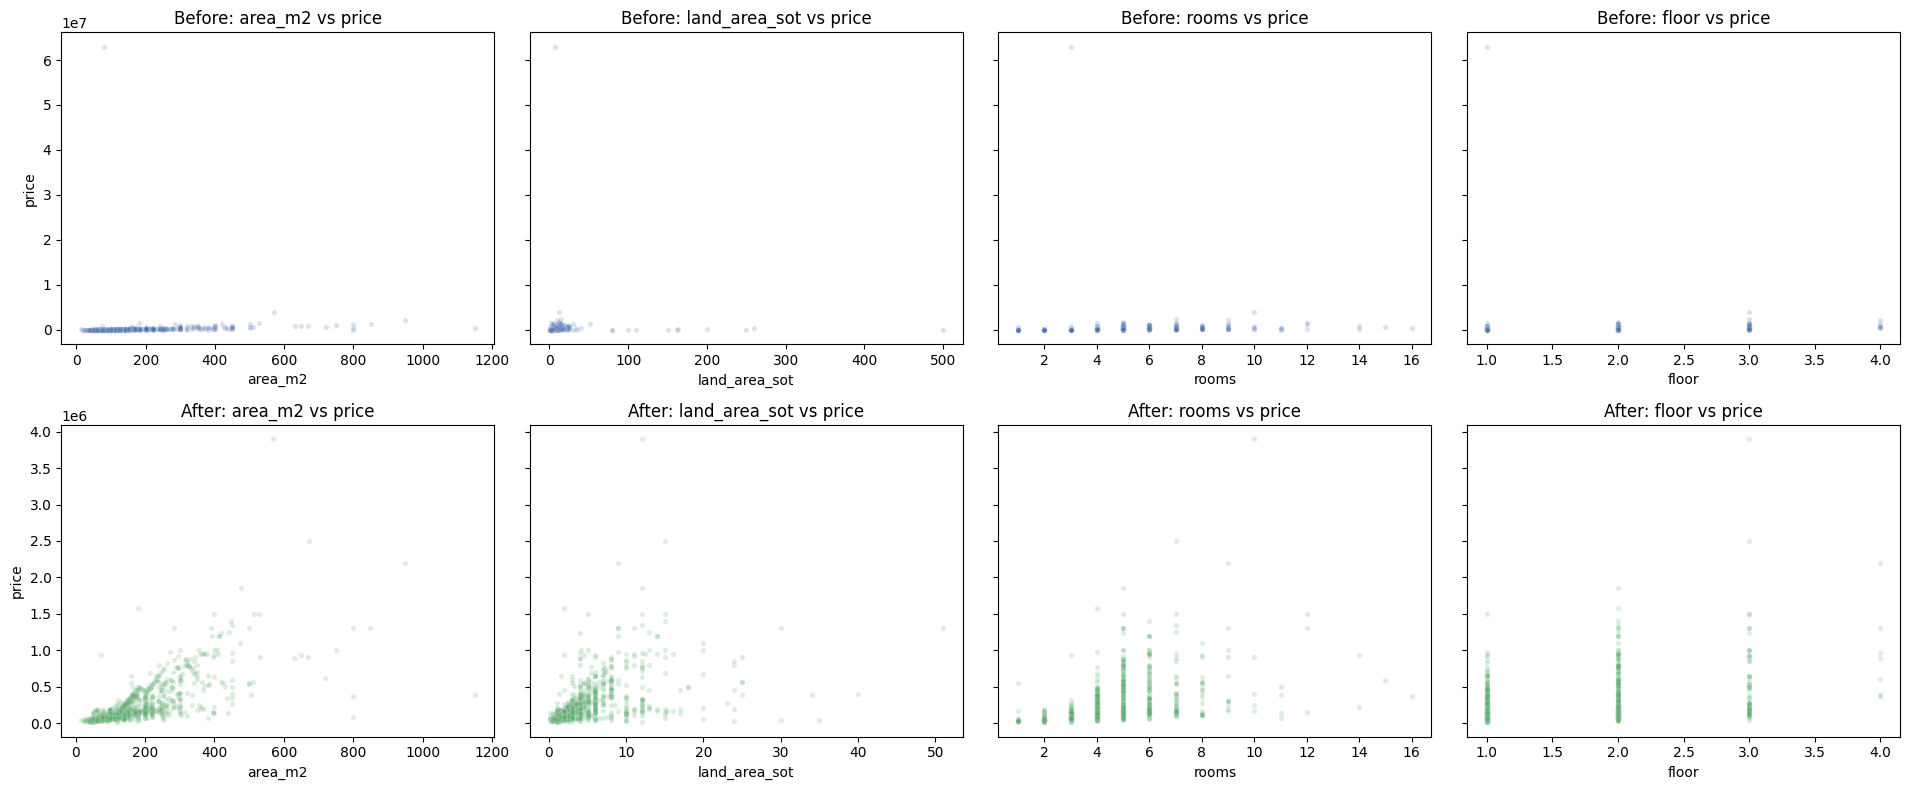

In [31]:
if "df_before_cleaning" not in globals():
    df_before_cleaning = df.copy()

print("Before vs after distribution comparison:")
plot_before_after_distributions(df_before_cleaning, df_clean, key_numeric_features)

print("Correlation heatmap on cleaned dataset:")
plot_correlation_heatmap(df_clean, "Correlation Heatmap - Cleaned House Dataset")

comparison_features = [
    c for c in ["area_m2", "land_area_sot", "rooms", "floor"]
    if c in df_before_cleaning.columns and c in df_clean.columns
]

if "price" in df_before_cleaning.columns and "price" in df_clean.columns and comparison_features:
    fig, axes = plt.subplots(2, len(comparison_features), figsize=(4.8 * len(comparison_features), 8), sharey="row")
    if len(comparison_features) == 1:
        axes = np.array(axes).reshape(2, 1)

    for j, feature in enumerate(comparison_features):
        sns.scatterplot(
            data=df_before_cleaning,
            x=feature,
            y="price",
            alpha=0.2,
            s=14,
            color="#4C72B0",
            ax=axes[0, j]
        )
        axes[0, j].set_title(f"Before: {feature} vs price")

        sns.scatterplot(
            data=df_clean,
            x=feature,
            y="price",
            alpha=0.2,
            s=14,
            color="#55A868",
            ax=axes[1, j]
        )
        axes[1, j].set_title(f"After: {feature} vs price")

    plt.tight_layout()
    plt.show()
else:
    print("Skipping scatter diagnostics: required columns are missing.")

## Step 32 - Workflow Cell 32
Persist generated outputs and artifacts for downstream use.

In [32]:
df_clean.to_csv('../../data/house/satilir_properties_house_cleaned.csv', index=False)
print("Cleaned dataset saved to 'data/house/satilir_properties_house_cleaned.csv'")

Cleaned dataset saved to 'data/house/satilir_properties_house_cleaned.csv'
